# Lab 7 - Power Spectral Analysis

In this notebook, we'll build on our periodogram demos from Lecture 12 and explore:
1. The Discrete Fourier Transform (DFT) and its connection to the periodogram
2. Spectral density of common processes (white noise, MA, AR)
3. Linear filtering in the frequency domain

**Cells marked with `# TODO` are for you to fill in!**

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import math
from scipy.signal import periodogram
plt.rcParams['figure.figsize'] = (5, 3)

## Part 1: The Discrete Fourier Transform (DFT)

Recall from last lecture that the periodogram used coefficients:

$$a_j = \frac{2}{n}\sum_{t=1}^n x_t \cos(2\pi t j/n), \quad b_j = \frac{2}{n}\sum_{t=1}^n x_t \sin(2\pi t j/n)$$

The DFT wraps these together using Euler's formula $e^{-i\theta}=\cos\theta - i\sin\theta$:

$$d(j/n) = \frac{1}{\sqrt{n}}\sum_{t=1}^n x_t e^{-i 2\pi t j/n}$$

And the scaled periodogram is $P(j/n) = \frac{4}{n}|d(j/n)|^2$.

Let's implement the DFT by hand and compare it to `numpy.fft.fft`.

### Implement the DFT manually

Write a function that computes $d(j/n)$ for all $j = 0, 1, \dots, n-1$.

In [7]:
def dft(x):
    '''Compute the Discrete Fourier Transform of signal x.
    
    Parameters
    ----------
    x : array of length n
    
    Returns
    -------
    d : complex array of length n, where d[j] = d(j/n)
    '''
    n = len(x)
    t = np.arange(1, n + 1)  # t = 1, ..., n
    d = np.zeros(n, dtype=complex)
    
    for j in range(n):
        # TODO: Compute d[j] using the DFT formula
        # Hint: d[j] = (1/sqrt(n)) * sum of x_t * exp(-i * 2pi * t * j / n)
        d[j] = 1/np.sqrt(n) * np.sum(x*np.exp(-1j*2*math.pi*t*j/n))  # FILL IN
    
    return d

### Compare your DFT to numpy's FFT

Note: `numpy.fft.fft` uses the convention $X[j] = \sum_{t=0}^{n-1} x_t e^{-i 2\pi t j/n}$ (no $1/\sqrt{n}$ scaling, and $t$ starts at 0). So to compare, we need to account for the different normalization and indexing.

Max difference between manual and numpy DFT: 1.5169458873047464e-13


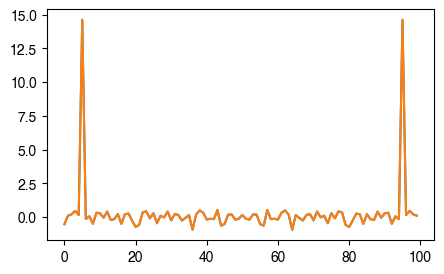

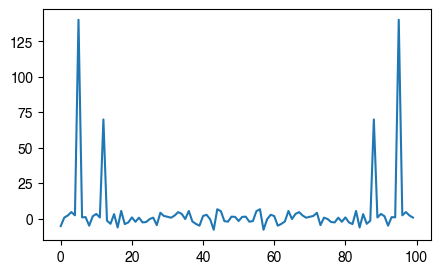

In [13]:
# Create a test signal: sum of two sinusoids + noise
np.random.seed(42)
n = 100
t = np.arange(1, n+1)
x = 3*np.cos(2*math.pi*t*5/n) + 2*np.sin(2*math.pi*t*12/n) + np.random.normal(0, 0.5, n)

# Compute using your function
d_manual = dft(x)

# Compute using numpy (adjust for our convention)
# numpy uses t=0,...,n-1 and no 1/sqrt(n) normalization
# Our convention uses t=1,...,n and 1/sqrt(n)
# To match: multiply numpy result by exp(-i*2pi*j/n)/sqrt(n) to shift from 0-indexing to 1-indexing
fft_numpy = np.fft.fft(x)
j_vals = np.arange(n)
d_numpy = 1/np.sqrt(n) * fft_numpy * np.exp(-1j * 2 * math.pi * j_vals / n)

# Check they match
plt.figure()
plt.plot(d_manual)
plt.plot(d_numpy)

plt.figure()
plt.plot(fft_numpy)
print("Max difference between manual and numpy DFT:", np.max(np.abs(d_manual - d_numpy)))

### From DFT to periodogram

The scaled periodogram is $P(j/n) = \frac{4}{n}|d(j/n)|^2$. Let's compute it from the DFT and compare to `scipy.signal.periodogram`.

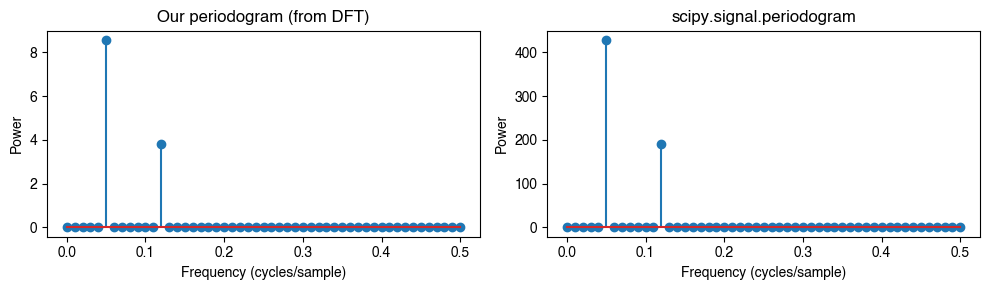

In [15]:
# Compute the scaled periodogram from our DFT
# TODO: Fill in the periodogram formula
P_manual = (4/n) * np.abs(d_manual)**2  # FILL IN: (4/n) * |d(j/n)|^2

# Only plot up to the Nyquist frequency (j = 0, ..., n/2)
freqs_manual = np.arange(n // 2 + 1) / n  # frequencies j/n

# Compare with scipy periodogram (fs=1 so frequencies are in cycles/sample)
freqs_scipy, power_scipy = periodogram(x, fs=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].stem(freqs_manual, P_manual[:n // 2 + 1])
axes[0].set_title('Our periodogram (from DFT)')
axes[0].set_xlabel('Frequency (cycles/sample)')
axes[0].set_ylabel('Power')

axes[1].stem(freqs_scipy, power_scipy)
axes[1].set_title('scipy.signal.periodogram')
axes[1].set_xlabel('Frequency (cycles/sample)')
axes[1].set_ylabel('Power')
plt.tight_layout()

# Note: scipy uses a slightly different normalization. The shapes should match
# even if the scale differs. What normalization does scipy use?

### The symmetry property

We noted that $P(j/n) = P(1 - j/n)$, which is why we only need to look at frequencies up to 1/2. Let's verify this.

In [16]:
# TODO: Verify that |d(j/n)|^2 = |d(1-j/n)|^2 for our test signal
# Hint: d(1 - j/n) corresponds to index (n - j) in the array

for j in range(1, 6):
    power_j = np.abs(d_manual[j])**2
    power_mirror = np.abs(d_manual[n-j])**2  # FILL IN: |d[n-j]|^2
    print(f"j={j}: |d(j/n)|^2 = {power_j:.4f}, |d(1-j/n)|^2 = {power_mirror:.4f}")

j=1: |d(j/n)|^2 = 0.3022, |d(1-j/n)|^2 = 0.3022
j=2: |d(j/n)|^2 = 0.0796, |d(1-j/n)|^2 = 0.0796
j=3: |d(j/n)|^2 = 0.2221, |d(1-j/n)|^2 = 0.2221
j=4: |d(j/n)|^2 = 0.1463, |d(1-j/n)|^2 = 0.1463
j=5: |d(j/n)|^2 = 214.0105, |d(1-j/n)|^2 = 214.0105


Why does this symmetry hold? What does it tell us about the information content of the DFT?

---
## Part 2: Spectral Density of Common Processes

The spectral density is the theoretical quantity that the periodogram estimates:

$$f(\omega) = \sum_{h=-\infty}^{\infty} \gamma(h) e^{-2\pi i \omega h}$$

Let's compute and visualize the theoretical spectra and compare them to periodograms from simulated data.

### White noise spectrum

For white noise, $\gamma(h) = \sigma_w^2$ when $h=0$ and $0$ otherwise. So the spectral density is simply $f(\omega) = \sigma_w^2$. That is, it is flat across all frequencies.

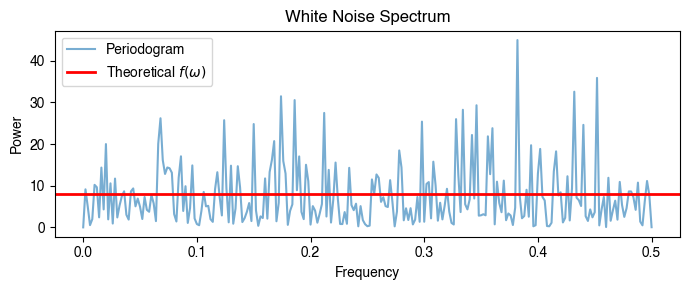

In [26]:
np.random.seed(42)
sigma_w = 2.0
n = 500

# Generate white noise
wn = np.random.normal(0, sigma_w, n)

# Compute the periodogram
freqs_wn, power_wn = periodogram(wn, fs=1)

# Plot periodogram vs. theoretical spectrum
plt.figure(figsize=(7, 3))
plt.plot(freqs_wn, power_wn, alpha=0.6, label='Periodogram')

# TODO: Plot the theoretical spectral density as a horizontal line
# Hint: For white noise, f(omega) = sigma_w^2
# But note scipy's periodogram normalization, so you may need to adjust by a factor.
# The total area under the periodogram should equal the variance.
# Note that scipy.signal.periodogram returns a one-sided spectrum by default (only [0,1/2]),
# which folds the negative-frequency power onto the positive side,
# effectively doubling the values.
plt.axhline(2*sigma_w**2, color='r', linewidth=2, label='Theoretical $f(\omega)$')  # FILL IN

plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('White Noise Spectrum')
plt.legend()
plt.tight_layout()

The periodogram looks very noisy even though the *theoretical* spectrum is flat. Why? Does increasing $n$ help?

In this case, increasing $n$ actually doesn't help! You can estimate power at more and more frequencies, but the noise per bin stays the same. 

---
## Part 3: Linear Filtering in the Frequency Domain

A linear filter transforms $x_t$ into $y_t = \sum_j a_j x_{t-j}$.

In the frequency domain, the output spectrum is:
$$f_y(\omega) = |A(\omega)|^2 f_x(\omega)$$

where $A(\omega) = \sum_j a_j e^{-2\pi i \omega j}$ is the *frequency response function*.

This is powerful because **convolution in time becomes multiplication in frequency**.

### Simple moving average as a low-pass filter

A simple moving average of order $m$ uses weights $a_j = 1/m$ for $j = 0, 1, \dots, m-1$. Let's see how this reshapes the spectrum.

In [27]:
def frequency_response_ma(omega, m):
    '''Compute |A(omega)|^2 for a simple moving average filter of order m.
    
    A(omega) = (1/m) * sum_{j=0}^{m-1} exp(-2*pi*i*omega*j)
    '''
    # TODO: Compute A(omega) and return |A(omega)|^2
    # Hint: you can compute the sum using a loop or the geometric series formula
    A = np.zeros_like(omega, dtype=complex)
    for j in range(m):
        A += (1/m) * np.exp(-2*math.pi*1j*omega*j)  # FILL IN: (1/m) * exp(-2*pi*i*omega*j)
    return np.abs(A)**2

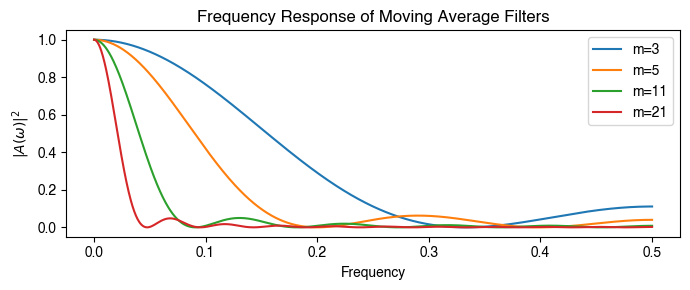

In [28]:
omega = np.linspace(0, 0.5, 1000)

plt.figure(figsize=(7, 3))
for m in [3, 5, 11, 21]:
    plt.plot(omega, frequency_response_ma(omega, m), label=f'm={m}')

plt.xlabel('Frequency')
plt.ylabel('$|A(\omega)|^2$')
plt.title('Frequency Response of Moving Average Filters')
plt.legend()
plt.tight_layout()

The simple moving average is called a "low-pass" filter. From looking at the plot above, what do you think this means? What happens to the frequencies as $m$ increases?

### Filtering a noisy signal

Now let's create a signal with a clear low-frequency component plus high-frequency noise, then apply a moving average filter and see how the spectrum changes.

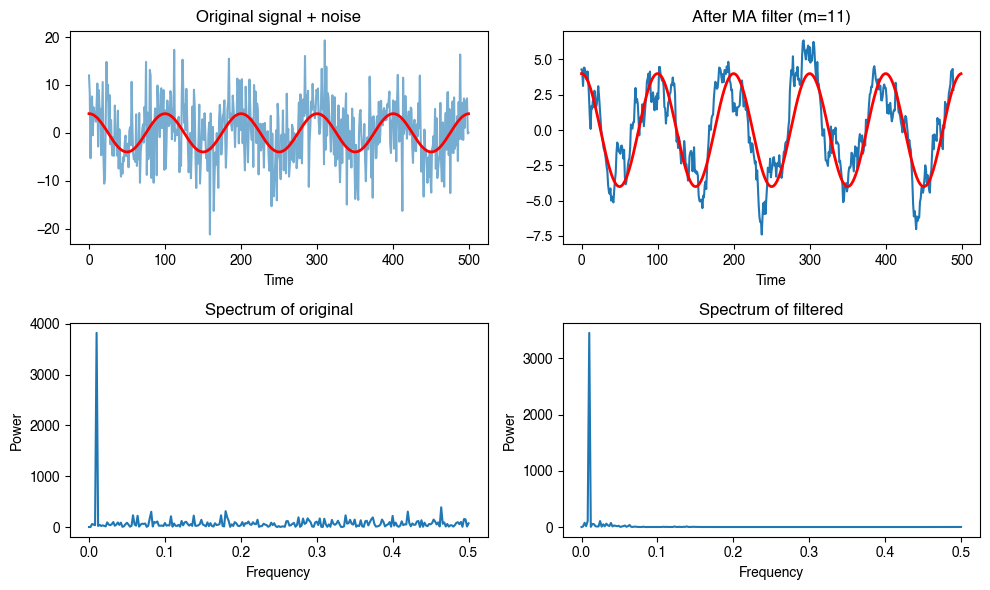

In [37]:
np.random.seed(10)
n = 500
t = np.arange(n)

# Signal: slow sinusoid + noise
signal = 4*np.cos(2*math.pi*t*5/n)  # 5 cycles over n points
noise = np.random.normal(0, 6, n)
x = signal + noise

# Apply a moving average filter of order m
m = 11

# TODO: Compute the filtered signal using np.convolve with weights 1/m
weights = np.ones(m) / m
y = np.convolve(x, weights, mode='valid')  # FILL IN: use np.convolve(x, weights, mode='valid')

# Plot time domain
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.plot(t, x, alpha=0.6)
plt.plot(t, signal, 'r', linewidth=2)
plt.title('Original signal + noise')
plt.xlabel('Time')

plt.subplot(2,2,2)
plt.plot(y)
plt.plot(t, signal, 'r', linewidth=2)
plt.title(f'After MA filter (m={m})')
plt.xlabel('Time')

# Plot frequency domain
freqs_x, power_x = periodogram(x, fs=1)
freqs_y, power_y = periodogram(y, fs=1)

plt.subplot(2,2,3)
plt.plot(freqs_x, power_x)
plt.title('Spectrum of original')
plt.xlabel('Frequency')
plt.ylabel('Power')

plt.subplot(2,2,4)
plt.plot(freqs_y, power_y)
plt.title('Spectrum of filtered')
plt.xlabel('Frequency')
plt.ylabel('Power')

plt.tight_layout()

What do you notice about how both the time series and the frequency spectrum change after the filtering?

### First-difference filter as a high-pass filter

Taking first differences ($y_t = x_t - x_{t-1}$) is a common operation for removing trends. This is a linear filter with $a_0 = 1, a_1 = -1$.

In [38]:
def frequency_response_diff(omega):
    '''
    Compute |A(omega)|^2 for the first-difference filter.
    
    A(omega) = 1 - exp(-2*pi*i*omega)
    '''
    # TODO: Compute |A(omega)|^2
    # Hint: You can show analytically that |A(omega)|^2 = 2 - 2*cos(2*pi*omega)
    return 2-2*np.cos(2*math.pi*omega)  # FILL IN

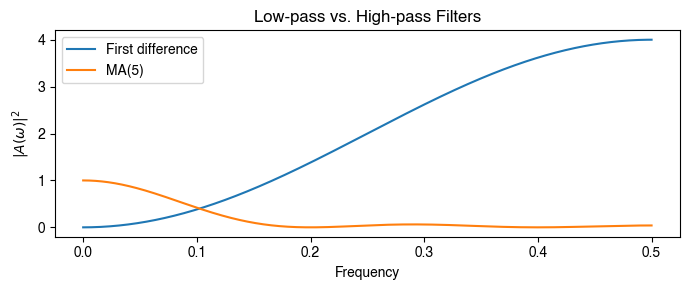

In [39]:
omega = np.linspace(0, 0.5, 1000)

plt.figure(figsize=(7, 3))
plt.plot(omega, frequency_response_diff(omega), label='First difference')
plt.plot(omega, frequency_response_ma(omega, 5), label='MA(5)')
plt.xlabel('Frequency')
plt.ylabel('$|A(\omega)|^2$')
plt.title('Low-pass vs. High-pass Filters')
plt.legend()
plt.tight_layout()

Why does differencing remove trends? Think about what a trend looks like in the frequency domain.

---
## Part 4: Periodogram as a Noisy Estimator

An important property of the periodogram: it is an **inconsistent** estimator of the spectral density. Even as $n \to \infty$, the periodogram does not converge to $f(\omega)$ — its variance doesn't shrink! Let's see this.

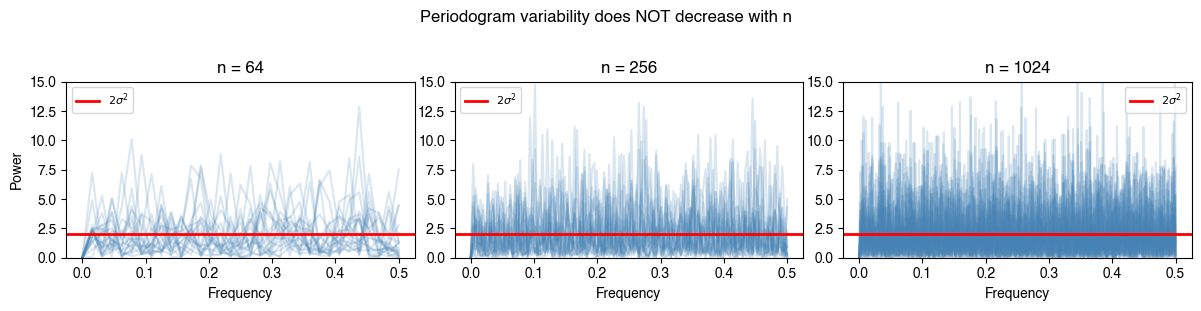

In [40]:
# Simulate many periodograms from white noise and overlay them
np.random.seed(42)
sigma2 = 1.0

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for idx, n in enumerate([64, 256, 1024]):
    for rep in range(20):
        wn = np.random.normal(0, np.sqrt(sigma2), n)
        freqs, power = periodogram(wn, fs=1)
        axes[idx].plot(freqs, power, alpha=0.2, color='steelblue')
    
    axes[idx].axhline(2 * sigma2, color='r', linewidth=2, label='$2\sigma^2$')
    axes[idx].set_title(f'n = {n}')
    axes[idx].set_xlabel('Frequency')
    axes[idx].set_ylim([0, 15])
    if idx == 0:
        axes[idx].set_ylabel('Power')
    axes[idx].legend(fontsize=8)

plt.suptitle('Periodogram variability does NOT decrease with n', y=1.02)
plt.tight_layout()

Why is the periodogram inconsistent? What could we do to get a better (smoother) estimate of the spectral density? (Hint: Think about averaging nearby frequencies — we'll cover this next lecture!)